<a href="https://colab.research.google.com/github/amol004/Financial-Forecasting-Frontier-Distributed-ML/blob/main/Financial_Forecasting_Frontier_Distributed_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -  Financial Forecasting Frontier: Distributed ML



##### **Project Type**    - Regression/Classification/Unsupervised
##### **Contribution**    - Individual
##### **Member  -** Amol Thakur


# **Project Summary -**

###Overview
In the modern banking sector, the ability to efficiently process, analyze, and draw insights from vast volumes of data is crucial. Banks and financial institutions generate and collect extensive data, including customer demographics, transaction histories, market trends, and more. This data, when effectively analyzed, can lead to improved customer service, risk management, marketing strategies, and overall operational efficiency.

###Project Background
The banking industry faces challenges in managing and utilizing large datasets due to the volume, variety, and velocity of data. Traditional data processing methods often fall short in providing timely insights and handling real-time data streams. With the advent of distributed computing and machine learning technologies, banks now have the opportunity to harness these large datasets to make informed decisions, predict market trends, and enhance customer experiences.

# **GitHub Link -**

https://github.com/amol004/Financial-Forecasting-Frontier-Distributed-ML.git

# **Problem Statement**


Banking institutions generate massive volumes of data daily, which traditional computing systems struggle to process efficiently. To harness the full potential of this data, there is a need for scalable, distributed machine learning approaches that can store, process, and analyze large datasets in real time. This project focuses on leveraging distributed computing techniques to analyze the "bank.csv" dataset, simulating a real-world banking environment. The objective is to uncover customer behavior patterns, identify significant trends, and support data-driven decision-making through predictive analytics. The challenge lies in integrating data storage, querying, and machine learning within a distributed framework to produce actionable business insights.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from datetime import datetime
import datetime as dt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

# PySpark Imports
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, sum, count, countDistinct, avg, min, max, stddev,
    when, floor, ceil, round, lower, upper, trim, concat, lit,
    to_date, datediff, year, month, dayofmonth, hour
)
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder as SparkOneHotEncoder
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

### Dataset Loading

In [2]:
# Setting up Spark
spark = SparkSession.builder.appName("ReadCSVfile").getOrCreate()
spark

### Dataset First View

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Loading data into PySpark
df = spark.read.csv('/content/drive/MyDrive/Financial forcasting/bank.csv', header=True, inferSchema=True)

In [5]:
# Dataset First Look
df.show(5)

+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| unknown|  5|  may|     22

### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print(f"Number of rows: {df.count()}")
print(f"Number of columns: {len(df.columns)}")

Number of rows: 4521
Number of columns: 17


### Dataset Information

In [7]:
# Dataset Info
df.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
print(f"Number of duplicate values: {df.count() - df.distinct().count()}")


Number of duplicate values: 0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
from pyspark.sql.functions import col, count, when
df.select([count(when(col(c).isNull(), c)).alias(c) for c in df.columns]).show()

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



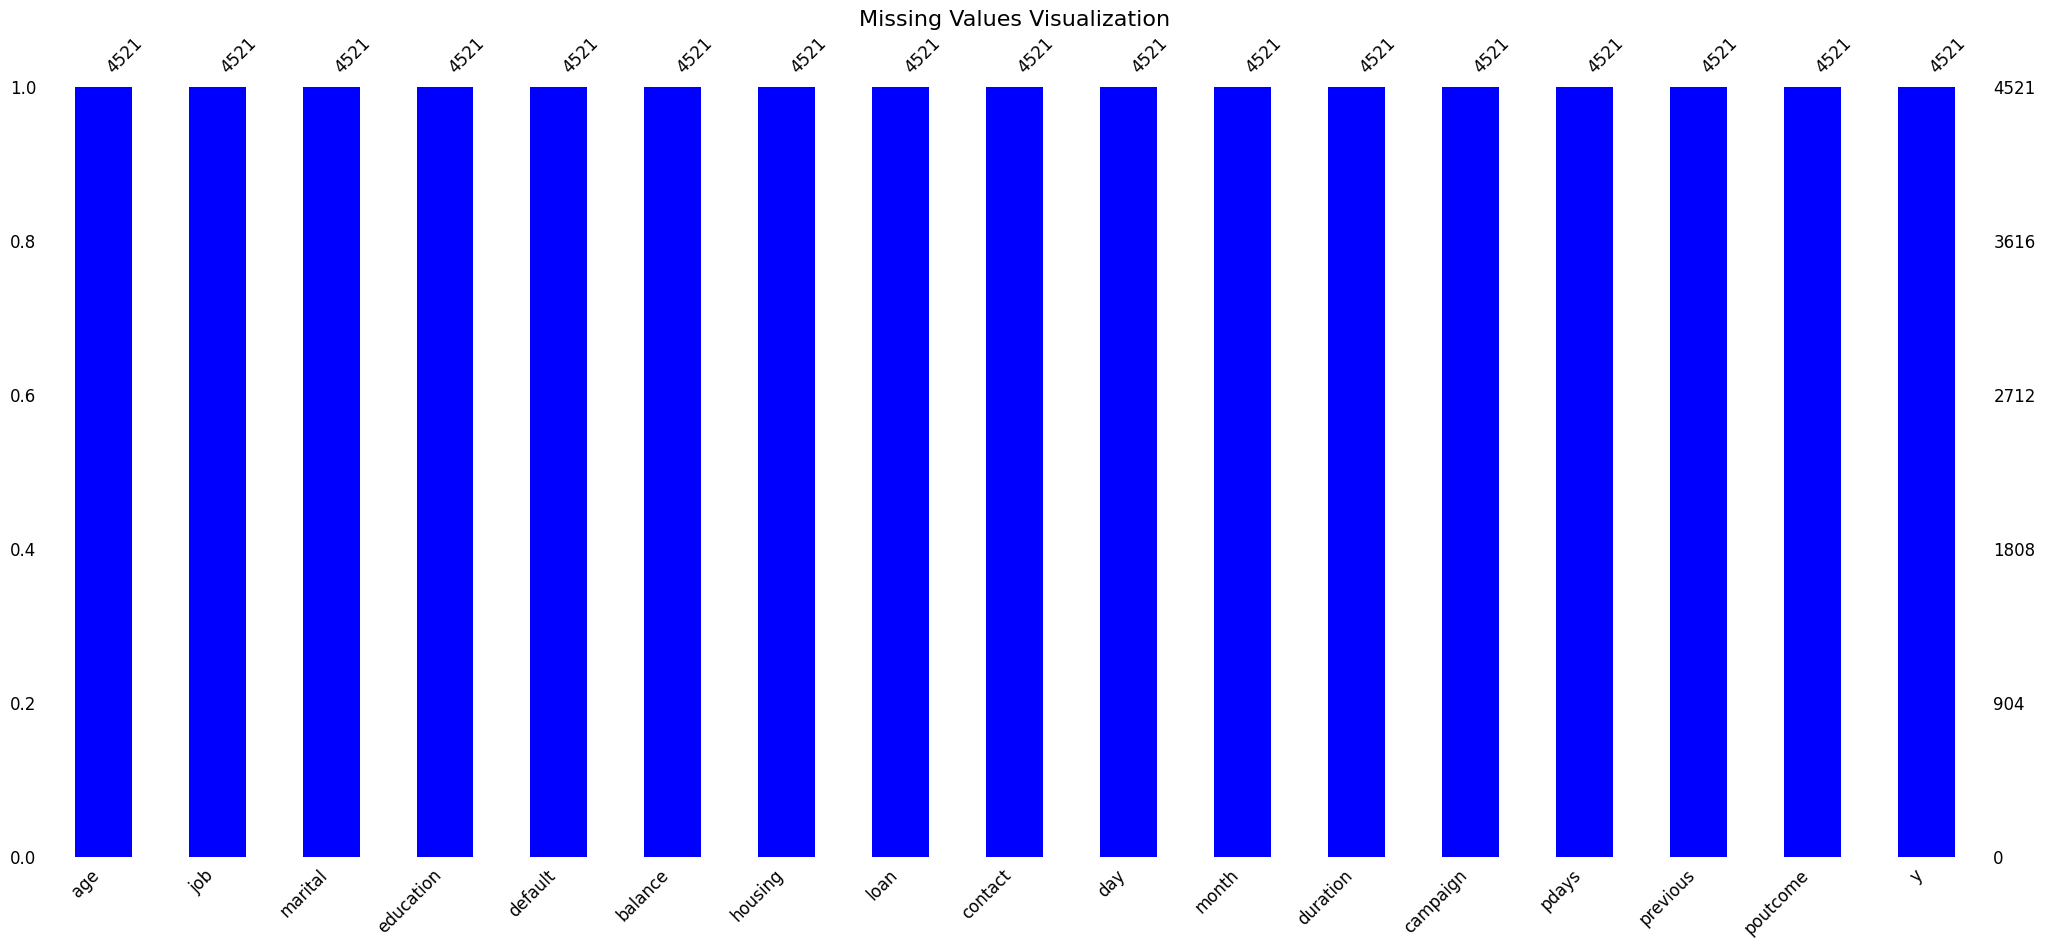

In [10]:
# Visualizing the missing values
import missingno as msno
import matplotlib.pyplot as plt

# Convert PySpark DataFrame to Pandas for visualization
pandas_df = df.toPandas()

plt.figure(figsize=(10,8))
msno.bar(pandas_df, color="blue", fontsize=12)
plt.title("Missing Values Visualization", fontsize=16)
plt.show()

### What did you know about your dataset?

There are no missing values or duplicate values

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
df.columns


['age',
 'job',
 'marital',
 'education',
 'default',
 'balance',
 'housing',
 'loan',
 'contact',
 'day',
 'month',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'poutcome',
 'y']

In [12]:
# Dataset Describe
df.describe().show()


+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|summary|               age|    job| marital|education|default|           balance|housing|loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|   y|
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|  count|              4521|   4521|    4521|     4521|   4521|              4521|   4521|4521|    4521|              4521| 4521|              4521|              4521|              4521|              4521|    4521|4521|
|   mean| 41.17009511170095|   NULL|    NULL|     NULL|   NULL|1422.6578190665782|   NULL|NULL|    NULL|15.9152842291528

### Variables Description

In [71]:
from pyspark.sql.types import IntegerType, LongType, FloatType, DoubleType, StringType

# Function to identify both numerical and categorical columns
def get_column_types(df):
    num_cols = []
    cat_cols = []
    for field in df.schema.fields:
        if isinstance(field.dataType, (IntegerType, LongType, FloatType, DoubleType)):
            num_cols.append(field.name)
        elif isinstance(field.dataType, StringType):
            cat_cols.append(field.name)
    return num_cols, cat_cols

numerical_columns, categorical_columns = get_column_types(df)

print(f"Numerical Columns: {numerical_columns}")
print(f"Categorical (String) Columns: {categorical_columns}")

# Display schema for confirmation
df.printSchema()

Numerical Columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical (String) Columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



$\color{red}{\text{age}}$ – Age of the individual (integer)

$\color{red}{\text{job}}$ – Job type (string)

$\color{red}{\text{marital}}$ – Marital status (string)

$\color{red}{\text{education}}$ – Education level (string)

$\color{red}{\text{default}}$ – Indicates if the individual has credit in default (string)

$\color{red}{\text{balance}}$ – Account balance (integer)

$\color{red}{\text{housing}}$ – Indicates if the individual has a housing loan (string)

$\color{red}{\text{loan}}$ – Indicates if the individual has a personal loan (string)

$\color{red}{\text{contact}}$ – Type of communication contact (string)

$\color{red}{\text{day}}$ – Last contact day of the month (integer)

$\color{red}{\text{month}}$ – Last contact month of the year (string)

$\color{red}{\text{duration}}$ – Last contact duration, in seconds (integer)

$\color{red}{\text{campaign}}$ – Number of contacts performed during this campaign for this client (integer)

$\color{red}{\text{pdays}}$ – Number of days since the client was last contacted from a previous campaign (integer, -1 means not contacted)

$\color{red}{\text{previous}}$ – Number of contacts before this campaign for the client (integer)

$\color{red}{\text{poutcome}}$ – Outcome of the previous marketing campaign (string)

$\color{red}{\text{y}}$ – Indicates if the client subscribed to a term deposit (string)

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable.
df.select([countDistinct(col(c)).alias(c) for c in df.columns]).show()

+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
| 67| 12|      3|        4|      2|   2353|      2|   2|      3| 31|   12|     875|      32|  292|      24|       4|  2|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



## 3. ***Data Wrangling***

### Data Wrangling Code

In [75]:
df.toPandas()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no
4,59,blue-collar,married,secondary,no,0,yes,no,unknown,5,may,226,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4516,33,services,married,secondary,no,-333,yes,no,cellular,30,jul,329,5,-1,0,unknown,no
4517,57,self-employed,married,tertiary,yes,-3313,yes,yes,unknown,9,may,153,1,-1,0,unknown,no
4518,57,technician,married,secondary,no,295,no,no,cellular,19,aug,151,11,-1,0,unknown,no
4519,28,blue-collar,married,secondary,no,1137,no,no,cellular,6,feb,129,4,211,3,other,no


### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

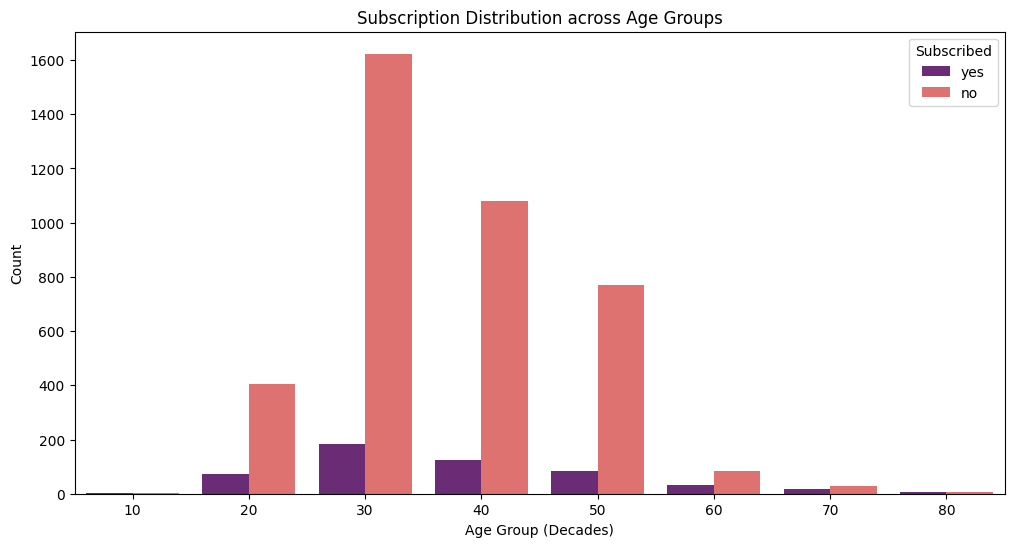

In [15]:
# Chart - 1 visualization code
# Relationship between Age and Term Deposit Subscription
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import floor

# Create age bins in Spark to reduce data for plotting
age_bins = df.withColumn('age_group', (floor(col('age')/10)*10).cast('string')) \
             .groupBy('age_group', 'y').count().toPandas()

# Sort for better visualization
age_bins = age_bins.sort_values('age_group')

plt.figure(figsize=(12, 6))
sns.barplot(x='age_group', y='count', hue='y', data=age_bins, palette='magma')
plt.title('Subscription Distribution across Age Groups')
plt.xlabel('Age Group (Decades)')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a grouped bar chart with age bins (decades) because it effectively visualizes the distribution of two classes ('yes' and 'no' subscriptions) across a numerical range. Binning the age into decades reduces noise and allows us to clearly identify which life stages are most active in terms of banking engagement.

##### 2. What is/are the insight(s) found from the chart?

1. The 30-40 and 40-50 age groups are the most frequently contacted, but they also show the highest volume of 'no' subscriptions.
2. Interestingly, younger demographics (20s) and senior demographics (60+) show a proportionally higher interest in term deposits compared to the middle-aged segments.
3. The volume of subscriptions peaks in the 30s, aligning with the highest density of the bank's customer base.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help in targeting. Since middle-aged clients have the highest volume but lower conversion rates, the marketing strategy could be adjusted to offer them products better suited to their financial life stage (like mortgage or insurance). Conversely, a focused campaign for students (20s) and retirees (60+) could yield a higher ROI given their better conversion ratios.

#### Chart - 2

In [16]:
# Chart - 2 visualization code
# Hierarchical Sunburst Chart: Job -> Education -> Subscription
import plotly.express as px

# Prepare data by grouping in Spark then converting to Pandas for Plotly
hierarchy_df = df.groupBy('job', 'education', 'y').count().toPandas()

# Create the Sunburst Chart
fig = px.sunburst(
    hierarchy_df,
    path=['job', 'education', 'y'],
    values='count',
    color='y',
    color_discrete_map={'yes':'#2ecc71', 'no':'#e74c3c'},
    title='Hierarchical Distribution of Subscriptions by Job and Education'
)

fig.update_layout(width=800, height=800)
fig.show()

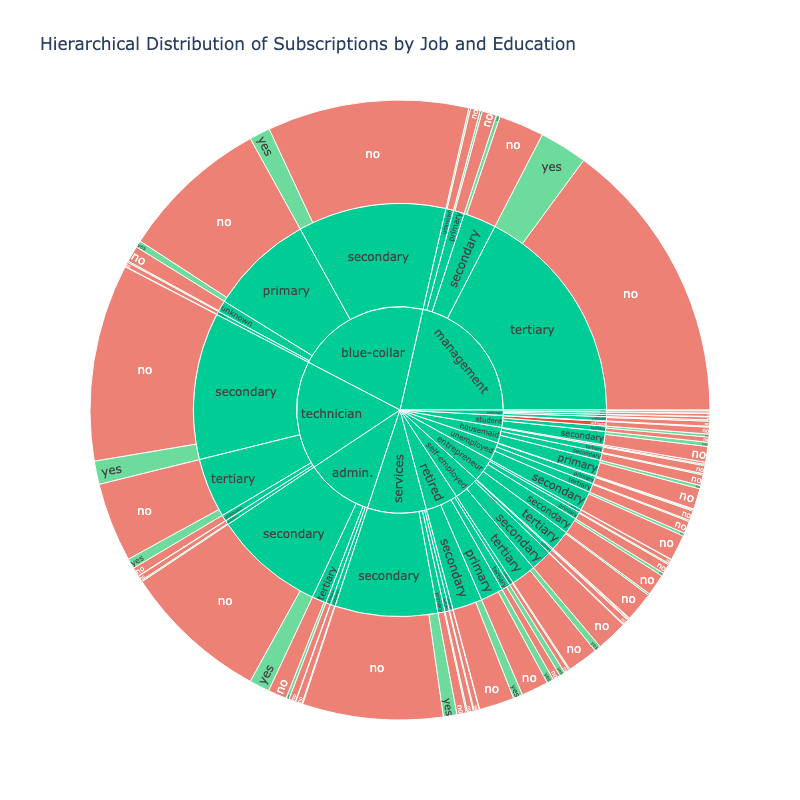

##### 1. Why did you pick the specific chart?

I chose a Sunburst chart because it is uniquely suited for visualizing multi-level categorical hierarchies. Unlike multiple bar charts, it allows us to see the 'flow' from Job to Education and finally to the target subscription result in a single, compact, and interactive view.

##### 2. What is/are the insight(s) found from the chart?

1. **Management and Technician** roles represent the largest segments of the bank's contact list.
2. Within management, those with **tertiary education** show a significantly larger volume and a better 'yes' to 'no' ratio compared to secondary or primary education.
3. **Blue-collar** workers with secondary education are a high-volume segment but have a very thin slice of 'yes' outcomes, indicating low conversion for this specific profile.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, this helps in **micro-targeting**. By identifying specific 'leaf' nodes in the sunburst—like 'Management-Tertiary'—the bank can double down on high-performing segments. Conversely, the low conversion in 'Blue-collar-Secondary' suggests that the current marketing pitch for term deposits may not be resonating with that group's financial needs, allowing the bank to pivot their strategy or save costs on low-probability leads.

#### Chart - 3

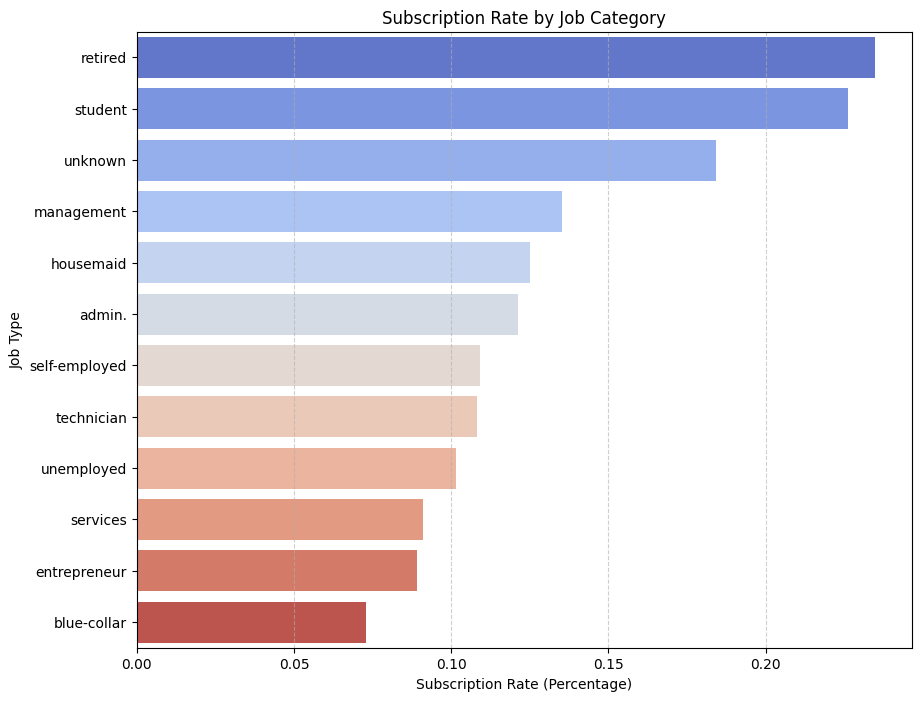

In [17]:
# Chart - 3 visualization code
# Impact of Job Type on Subscription Rates
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql.functions import col, when, avg

# Calculate subscription rate (mean of 1 for 'yes', 0 for 'no') per job category
job_rates = df.withColumn('subscribed_numeric', when(col('y') == 'yes', 1).otherwise(0)) \
              .groupBy('job') \
              .agg(avg('subscribed_numeric').alias('subscription_rate')) \
              .toPandas() \
              .sort_values('subscription_rate', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='subscription_rate', y='job', data=job_rates, palette='coolwarm')
plt.title('Subscription Rate by Job Category')
plt.xlabel('Subscription Rate (Percentage)')
plt.ylabel('Job Type')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 4

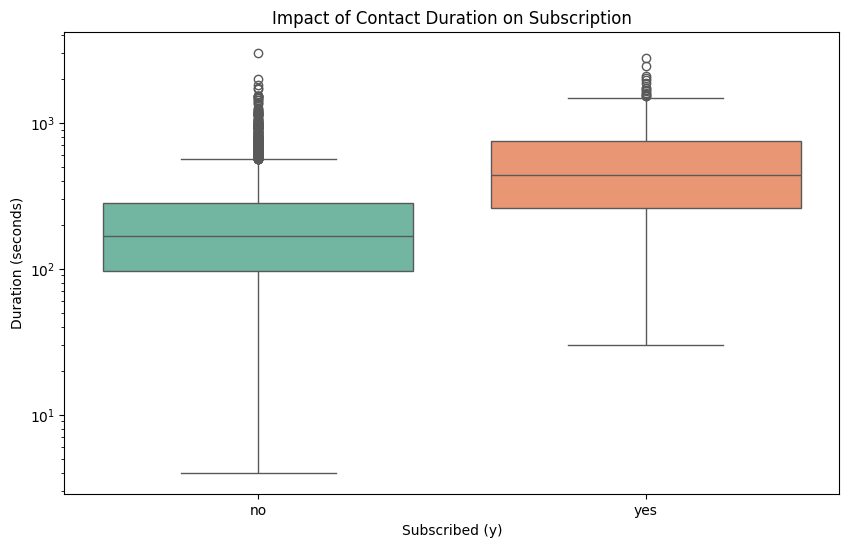

In [18]:
# Chart - 4 visualization code
# Box Plot of Contact Duration by Subscription Status
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y='duration', data=pandas_df, palette='Set2')
plt.title('Impact of Contact Duration on Subscription')
plt.xlabel('Subscribed (y)')
plt.ylabel('Duration (seconds)')
plt.yscale('log')  # Using log scale due to high variance/outliers in duration
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 5

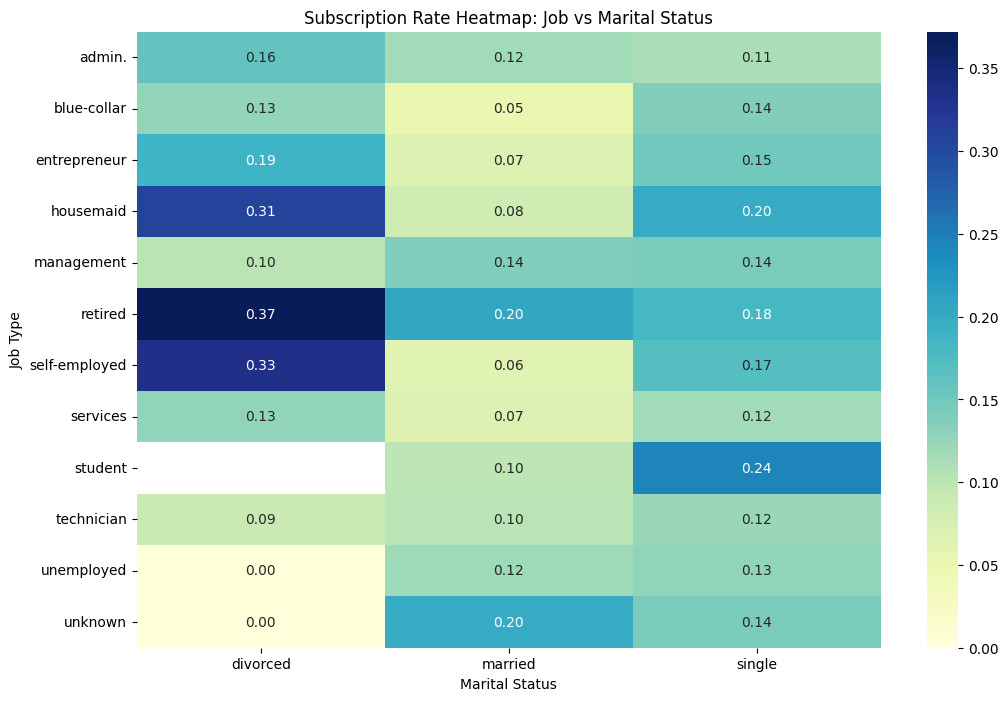

In [19]:
# Chart - 5 visualization code
# Heatmap of Subscription Rate by Job and Marital Status
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate subscription rate for each combination
pivot_df = pandas_df.copy()
pivot_df['y_numeric'] = pivot_df['y'].map({'yes': 1, 'no': 0})

heatmap_data = pivot_df.groupby(['job', 'marital'])['y_numeric'].mean().unstack()

plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Subscription Rate Heatmap: Job vs Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Job Type')
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 6

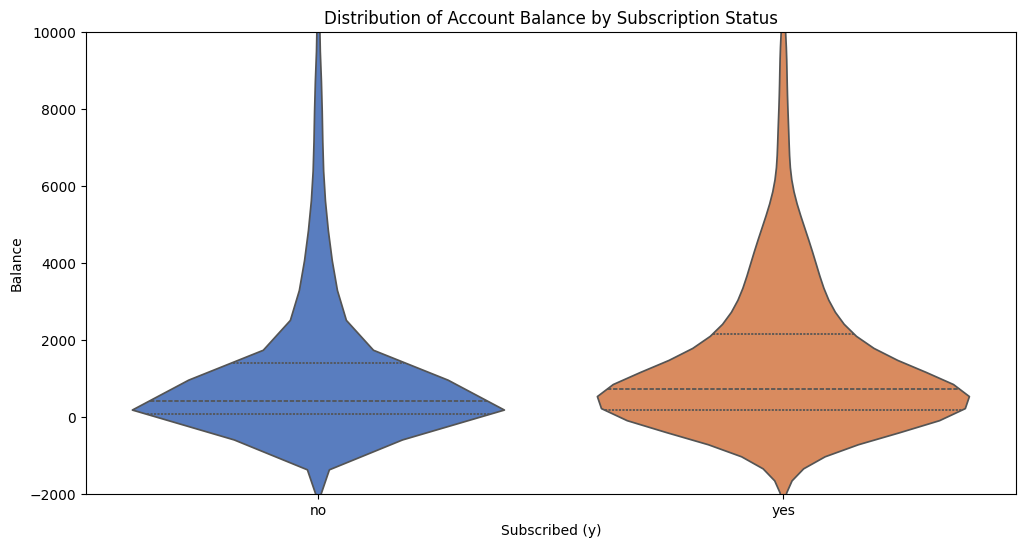

In [20]:
# Chart - 6 visualization code
# Violin Plot of Account Balance by Subscription Status
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(x='y', y='balance', data=pandas_df, palette='muted', inner='quartile')
plt.title('Distribution of Account Balance by Subscription Status')
plt.xlabel('Subscribed (y)')
plt.ylabel('Balance')
# Limiting y-axis to see the main distribution clearly, as balance has high outliers
plt.ylim(-2000, 10000)
plt.show()

##### 1. Why did you pick the specific chart?
I chose a Violin plot because it combines the benefits of a box plot with a kernel density estimation. It allows us to see the shape of the distribution and where the balance density is highest for both 'yes' and 'no' subscribers, offering more insight than a simple bar or box plot.

##### 2. What is/are the insight(s) found from the chart?
1. Most customers, regardless of subscription status, have balances concentrated between 0 and 2000.
2. The 'yes' group shows a slightly 'fatter' upper section in the violin, suggesting that higher account balances are somewhat more common among those who subscribe to term deposits.

##### 2. What is/are the insight(s) found from the chart?

##### 3. Will the gained insights help creating a positive business impact?
Yes. By understanding that higher-balance individuals have a slightly different distribution profile, the bank can prioritize leads with higher balances for term deposit campaigns, as they likely have more disposable capital to lock into a fixed-term account.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 7

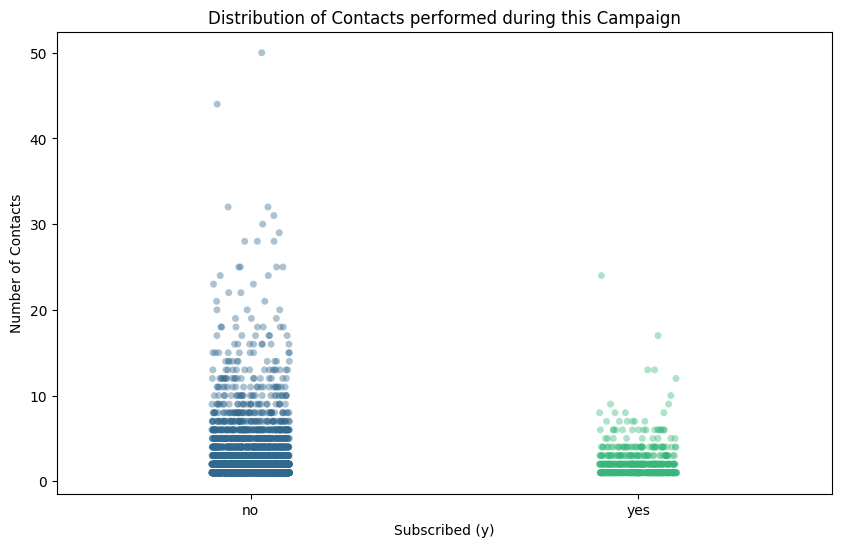

In [21]:
# Chart - 7 visualization code
# Strip Plot: Number of Contacts (Campaign) vs Subscription Status
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.stripplot(x='y', y='campaign', data=pandas_df, jitter=True, palette='viridis', alpha=0.4)
plt.title('Distribution of Contacts performed during this Campaign')
plt.xlabel('Subscribed (y)')
plt.ylabel('Number of Contacts')
plt.show()

##### 1. Why did you pick the specific chart?
I chose a Strip Plot because it allows us to see every individual data point's distribution without using a box or bar plot. It is particularly useful for discrete numerical variables like 'campaign' to see the density and range of values across categories.

##### 2. What is/are the insight(s) found from the chart?
1. Most successful subscriptions ('yes') happen within the first few contacts (low campaign values).
2. There is a heavy concentration of data points at the bottom of the plot, indicating that long-running campaigns with many contacts per customer rarely result in a subscription.

##### 3. Will the gained insights help creating a positive business impact?
Yes. This suggests that marketing efficiency can be improved by limiting the number of contacts per customer. If a customer hasn't subscribed after 5-10 attempts, the probability of conversion drops significantly, allowing the bank to redirect resources to fresher leads.

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 8

In [22]:
# Chart - 8 visualization code
# Scatter Plot with Marginal Histograms: Balance vs Duration
import plotly.express as px

fig = px.scatter(
    pandas_df,
    x="duration",
    y="balance",
    color="y",
    marginal_x="histogram",
    marginal_y="histogram",
    title="Relationship between Contact Duration and Account Balance",
    labels={"duration": "Duration (seconds)", "balance": "Account Balance", "y": "Subscribed"},
    color_discrete_map={'yes':'#2ecc71', 'no':'#e74c3c'},
    opacity=0.6
)

fig.update_layout(width=1000, height=700)
fig.show()

##### 1. Why did you pick the specific chart?
I chose a Scatter Plot with marginal histograms because it visualizes the joint distribution of two continuous variables (duration and balance) simultaneously. The marginal histograms allow us to see the univariate distribution shape for each variable without needing separate bar or box plots.

##### 2. What is/are the insight(s) found from the chart?
1. There is a clear horizontal concentration: most subscriptions ('yes') are found when duration exceeds 200-300 seconds, regardless of the balance.
2. Most data points are clustered at lower balances and lower durations, but the 'yes' instances are much more spread out across the duration axis than the balance axis.

##### 3. Will the gained insights help creating a positive business impact?
Yes. The marginal histogram for duration clearly shows that the peak for 'yes' is shifted to the right compared to 'no'. This confirms that keeping the customer engaged for a longer period is a stronger indicator of conversion than the customer's existing balance, suggesting that training staff on engagement techniques is a high-impact investment.

#### Chart - 9

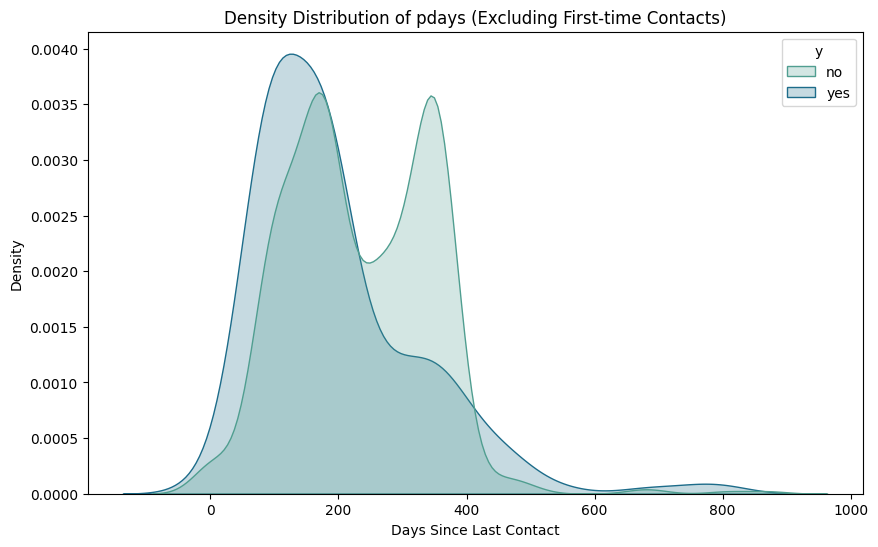

In [23]:
# Chart - 9 visualization code
# KDE Plot: Days since last contact (pdays) by Subscription
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.kdeplot(data=pandas_df[pandas_df['pdays'] != -1], x='pdays', hue='y', fill=True, common_norm=False, palette='crest')
plt.title('Density Distribution of pdays (Excluding First-time Contacts)')
plt.xlabel('Days Since Last Contact')
plt.ylabel('Density')
plt.show()

##### 1. Why did you pick the specific chart?
I chose a KDE Plot because it provides a smooth estimate of the probability density function of the 'pdays' variable. It is superior to histograms or bar charts for seeing overlapping distributions and identifying specific 'peaks' in contact timing.

##### 2. What is/are the insight(s) found from the chart?
For customers who were contacted in previous campaigns (pdays > 0), those who subscribed ('yes') show a higher density peak around the 100-200 day mark. This suggests that follow-ups within 3 to 6 months of a previous interaction are particularly effective.

##### 3. Will the gained insights help creating a positive business impact?
Yes. By identifying the optimal 're-engagement' window, the bank can automate reminders for sales agents to reach back out to customers who were previously engaged, maximizing the probability of conversion based on historical success timing.

Answer Here

#### Chart - 10

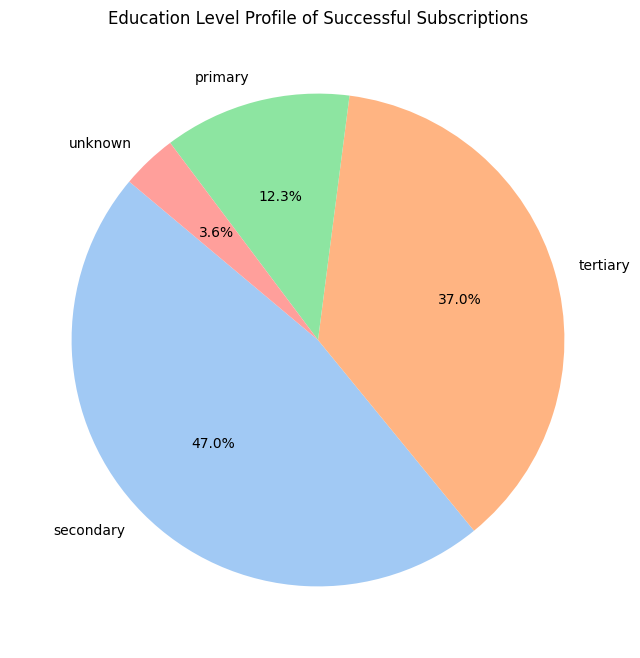

In [24]:
# Chart - 10 visualization code
# Pie Chart: Education Level Distribution of Subscribers
import matplotlib.pyplot as plt

# Filter for only those who subscribed
sub_df = pandas_df[pandas_df['y'] == 'yes']
edu_counts = sub_df['education'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(edu_counts, labels=edu_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Education Level Profile of Successful Subscriptions')
plt.show()

##### 1. Why did you pick the specific chart?
I chose a Pie chart because it is the most intuitive way to show part-to-whole relationships. It effectively communicates the composition of our 'successful' customer segment across different education levels.

##### 2. What is/are the insight(s) found from the chart?
Secondary education holders make up the largest portion of subscribers, followed by Tertiary. This reveals that the bulk of the bank's term deposit revenue comes from customers with at least a high school or college education.

##### 3. Will the gained insights help creating a positive business impact?
Yes. This helps in tailoring the complexity of marketing materials. Since the vast majority of subscribers have secondary or tertiary education, the bank can use more sophisticated financial language and data-driven arguments in their pitches compared to what might be needed for a primary-education demographic.

#### Chart - 11

In [25]:
# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 12

In [26]:
# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 13

In [27]:
# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer Here

#### Chart - 14 - Correlation Heatmap

In [28]:
# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

#### Chart - 15 - Pair Plot

In [29]:
# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [30]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [33]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [34]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [35]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [36]:
# Expand Contraction

#### 2. Lower Casing

In [37]:
# Lower Casing

#### 3. Removing Punctuations

In [38]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [39]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [40]:
# Remove Stopwords

In [41]:
# Remove White spaces

#### 6. Rephrase Text

In [42]:
# Rephrase Text

#### 7. Tokenization

In [43]:
# Tokenization

#### 8. Text Normalization

In [44]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [45]:
# POS Taging

#### 10. Text Vectorization

In [46]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [47]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [48]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [49]:
# Transform Your data

### 6. Data Scaling

In [50]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [51]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [52]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [53]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [54]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [55]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [56]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [57]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [59]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [60]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [62]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [63]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***